In [16]:
import os
from pathlib import Path
from ures.files import filter_files
from perf_estimator.estimator import Estimator
from perf_estimator.dataset import image_dataset
from experiments.snapshot import SnapshotAnalyser
from perf_estimator.profiler import ProfilerDataProcessing
from ures.string import format_memory


In [23]:
# Setup Basic Global Variables
# root_dir = Path("/Users/jiaboshi/Documents/101-Data/002-xMem-LLM")
root_dir = Path("/home/glaswigian/Documents/200-ResearchData/100-researchData/002-xMem-LLM/")
pytorch_dir = root_dir / "001-PyTorch"
huggingface_dir = root_dir / "002-HuggingFace"

pytorch_dir_name_format = "recurrence-{}-SGD-{}-1"
huggingface_dir_name_format_xmem = "{}-{}-xMem"
huggingface_dir_name_format_llm = "{}-{}-LLM"
huggingface_dir_name_format_cuda = "{}-{}-CUDA"

In [24]:
model = "VGG16"
batch_size = "170"
max_gpu_memory = 8

In [25]:
def get_xmem_memory(profiler_file, batch, max_in_gb):
    estimator = Estimator(
        dataloader=image_dataset(batch=int(batch)),
        profiler_file=profiler_file,
        max_gpu_memory_in_gb=max_in_gb
    )
    my_result, _ = estimator.estimate()
    return max(my_result._trace.max_segment_changes), estimator


def get_ground_value_from_snapshot(snapshot_file: str) -> dict:
    _snapshot = SnapshotAnalyser(snapshot_file)
    return _snapshot.gpu_and_segment_in_same_time_length()

import re

def extract_bytes(mem_list):
    """
    从每个内存条目中提取 Bytes 数值，返回排序后的数值列表。
    假设每个内存条目是一个字符串，格式中包含 "Bytes:<数字>"
    """
    bytes_values = []
    pattern = re.compile(r'Bytes:(\d+)')
    for item in mem_list:
        # 将 item 转换为字符串以防万一
        text = str(item)
        match = pattern.search(text)
        if match:
            bytes_values.append(int(match.group(1)))
    return sorted(bytes_values)

def compare_memory_bytes(list1, list2, debug=False):
    """
    比较两个列表中各模块的 forward_memory 和 backward_memory 中的 bytes 数值是否一致
    """
    # 构造成字典，以模块名称为 key
    dict1 = {entry['name']: entry for entry in list1}
    dict2 = {entry['name']: entry for entry in list2}
    forward_matched = True
    backwrd_matched = True

    # 得到所有模块名称
    all_names = set(dict1.keys()).union(dict2.keys())

    for name in all_names:
        entry1 = dict1.get(name)
        entry2 = dict2.get(name)

        if entry1 is None:
            print(f"模块 {name} 仅存在于第二个列表中。")
            continue
        if entry2 is None:
            print(f"模块 {name} 仅存在于第一个列表中。")
            continue

        # 分别提取 forward_memory 和 backward_memory 中的 bytes 数值
        forward_bytes1 = extract_bytes(entry1.get('forward_memory', []))
        forward_bytes2 = extract_bytes(entry2.get('forward_memory', []))
        backward_bytes1 = extract_bytes(entry1.get('backward_memory', []))
        backward_bytes2 = extract_bytes(entry2.get('backward_memory', []))

        if forward_bytes1 == forward_bytes2:
            if debug:
                print(f"{name}: forward_memory 的 bytes 匹配")
        else:
            forward_matched = False
            if debug:
                print(f"{name}: forward_memory 的 bytes 不匹配")
                print(f"  List1: {forward_bytes1}")
                print(f"  List2: {forward_bytes2}")

        if backward_bytes1 == backward_bytes2:
            if debug:
                print(f"{name}: backward_memory 的 bytes 匹配")
        else:
            backwrd_matched = False
            if debug:
                print(f"{name}: backward_memory 的 bytes 不匹配")
                print(f"  List1: {backward_bytes1}")
                print(f"  List2: {backward_bytes2}")

    return forward_matched, backwrd_matched


In [26]:
from typing import Union
def get_all_memory_information(model_name: str, batch: Union[str, int]) -> dict:
    batch = str(batch)
    # Get PyTorch Data
    torch_data_dir = pytorch_dir.joinpath(pytorch_dir_name_format.format(model_name, batch))
    all_torch_dirs = os.listdir(torch_data_dir)
    all_torch_dirs = [torch_data_dir.joinpath(d) for d in all_torch_dirs if str(d).startswith(".") is False]
    dirs_sorted = sorted(all_torch_dirs, key=lambda d: d.stat().st_ctime)
    torch_snapshot_file = filter_files(".pickle", dirs_sorted[0], fuzz=True)[-1]
    torch_profiler_file = filter_files(".pt.trace.json", dirs_sorted[0], fuzz=True)[-1]

    # Get HuggingFace Data
    huggingface_dir_xmem = huggingface_dir.joinpath(huggingface_dir_name_format_xmem.format(model_name, batch))
    huggingface_dir_cuda = huggingface_dir.joinpath(huggingface_dir_name_format_cuda.format(model_name, batch))
    huggingface_dir_llm = huggingface_dir.joinpath(huggingface_dir_name_format_llm.format(model_name, batch))
    huggingface_profiler_file_xmem = filter_files(".pt.trace.json", huggingface_dir_xmem, fuzz=True)[-1]
    huggingface_profiler_file_llm = filter_files(".pt.trace.json", huggingface_dir_llm, fuzz=True)[-1]
    huggingface_snapshot_file_xmem = filter_files(".pickle", huggingface_dir_cuda, fuzz=True)[-1]

    # Estimate memory
    huggingface_memory_llm, huggingface_estimator = get_xmem_memory(
        profiler_file=huggingface_profiler_file_llm,
        batch=batch_size,
        max_in_gb=max_gpu_memory
    )
    huggingface_snapshot_memory_xmen = max(get_ground_value_from_snapshot(huggingface_snapshot_file_xmem)['seg'])
    huggingface_memory_diff = huggingface_memory_llm - huggingface_snapshot_memory_xmen

    paper_memory_result, paper_estimator = get_xmem_memory(
        profiler_file=torch_profiler_file,
        batch=batch_size,
        max_in_gb=max_gpu_memory
    )
    paper_snapshot_result = max(get_ground_value_from_snapshot(torch_snapshot_file)['seg'])
    paper_memory_diff = paper_memory_result - paper_snapshot_result

    forward_matched, backward_matched = compare_memory_bytes(
        paper_estimator.profiler.get_iteration(1).layer_summary(),
        huggingface_estimator.profiler.get_iteration(1).layer_summary()
    )

    return {
        "torch": {
            "est": paper_memory_result,
            "ground": paper_snapshot_result,
            "error": round((abs(paper_memory_result - paper_snapshot_result)/paper_snapshot_result)*100, 2),
            "diff": paper_memory_diff
        },
        "huggingface": {
            "est": huggingface_memory_llm,
            "ground": huggingface_snapshot_memory_xmen,
            "error": round((abs(huggingface_memory_llm - huggingface_snapshot_memory_xmen)/huggingface_snapshot_memory_xmen)*100, 2),
            "diff": huggingface_memory_diff
        },
        "compare": {
            "forward": forward_matched,
            "backward": backward_matched,
            "groud_diff": paper_snapshot_result - huggingface_snapshot_memory_xmen
        }
    }


In [21]:
models = ["ConvNeXtTiny", "ResNet50", "VGG16"]
batch = range(10, 570, 40)

In [ ]:
result_list = []
for m in models:
    for b in batch:
        _r = get_all_memory_information(m, b)
        _r.update({
            "model": m,
            "batch": b
        })
        result_list.append(_r)

In [8]:
import pandas as pd
df = pd.json_normalize(result_list)

In [9]:
df

,model,batch,torch.est,torch.ground,torch.error,torch.diff,huggingface.est,huggingface.ground,huggingface.error,huggingface.diff,compare.forward,compare.backward,compare.groud_diff
0,ConvNeXtTiny,10,369098752,375390208,1.68,-6291456,260046848,262144000,0.80,-2097152,True,True,113246208
1,ConvNeXtTiny,50,994050048,723517440,37.39,270532608,882900992,958398464,7.88,-75497472,True,True,-234881024
2,ConvNeXtTiny,90,1614807040,1654652928,2.41,-39845888,1495269376,1629487104,8.24,-134217728,True,True,25165824
3,ConvNeXtTiny,130,2210398208,2449473536,9.76,-239075328,2097152000,2281701376,8.09,-184549376,True,True,167772160
4,ConvNeXtTiny,170,2824863744,2774532096,1.81,50331648,2713714688,2925527040,7.24,-211812352,True,True,-150994944
5,ConvNeXtTiny,210,3468689408,2774532096,25.02,694157312,3334471680,3590324224,7.13,-255852544,True,True,-815792128
6,ConvNeXtTiny,250,4106223616,4678746112,12.24,-572522496,3995074560,4280287232,6.66,-285212672,True,True,398458880
7,ConvNeXtTiny,290,4720689152,4615831552,2.27,104857600,4594860032,4945084416,7.08,-350224384,True,True,-329252864
8,ConvNeXtTiny,330,5368709120,5249171456,2.28,119537664,5232394240,5599395840,6.55,-367001600,True,True,-350224384
9,ConvNeXtTiny,370,5911871488,5771362304,2.43,140509184,5781848064,6199181312,6.73,-417333248,True,True,-427819008



# Analysis of Shopshot Data between PyTorch and HuggingFace


In [27]:
model_name = model
batch = batch_size
torch_data_dir = pytorch_dir.joinpath(pytorch_dir_name_format.format(model_name, batch))
all_torch_dirs = os.listdir(torch_data_dir)
all_torch_dirs = [torch_data_dir.joinpath(d) for d in all_torch_dirs if str(d).startswith(".") is False and str(d).startswith("@") is False]
dirs_sorted = sorted(all_torch_dirs, key=lambda d: d.stat().st_ctime)

In [28]:
torch_snapshot_file = Path(filter_files(".pickle", dirs_sorted[0], fuzz=True)[0])
torch_profiler_file = Path(filter_files(".pt.trace.json", dirs_sorted[0], fuzz=True)[-1])


In [29]:
# Get HuggingFace Data
huggingface_dir_xmem = huggingface_dir.joinpath(huggingface_dir_name_format_xmem.format(model_name, batch))
huggingface_dir_cuda = huggingface_dir.joinpath(huggingface_dir_name_format_cuda.format(model_name, batch))
huggingface_dir_llm = huggingface_dir.joinpath(huggingface_dir_name_format_llm.format(model_name, batch))
huggingface_profiler_file_xmem = filter_files(".pt.trace.json", huggingface_dir_xmem, fuzz=True)[-1]
huggingface_profiler_file_llm = filter_files(".pt.trace.json", huggingface_dir_llm, fuzz=True)[-1]
huggingface_snapshot_file_xmem = Path(filter_files(".pickle", huggingface_dir_cuda, fuzz=True)[-1])

torch_snapshot_file

PosixPath('/home/glaswigian/Documents/200-ResearchData/100-researchData/002-xMem-LLM/001-PyTorch/recurrence-VGG16-SGD-170-1/20241126-015141-d180/results/snapshot/snapshot_result-1732585963.pickle')

In [30]:
torch_snapshot = SnapshotAnalyser(torch_snapshot_file)
hugging_snapshot = SnapshotAnalyser(huggingface_snapshot_file_xmem)

In [31]:
torch_profiler = ProfilerDataProcessing(torch_profiler_file)

In [32]:
huggingface_profiler = ProfilerDataProcessing(huggingface_profiler_file_llm)
huggingface_profiler_file_llm

'/home/glaswigian/Documents/200-ResearchData/100-researchData/002-xMem-LLM/002-HuggingFace/VGG16-170-LLM/results/callback/Profiler/Glaswigian-Researcher_123964.1739486916203614949.pt.trace.json'

In [33]:
layer_in_torch = torch_profiler.get_iteration(2).layer_summary()
layer_in_hugging = huggingface_profiler.get_iteration(2).layer_summary()

In [34]:
_, torch_estimator = get_xmem_memory(torch_profiler_file, batch_size, max_gpu_memory)
_, hugging_estimator = get_xmem_memory(huggingface_profiler_file_llm, batch_size, max_gpu_memory)

In [35]:
training_memorys = torch_estimator.get_an_iteration_memory(iteration_index=2)
model_memory = torch_estimator.model_memory(iteration=2)
estimated_instance, estimated_result = torch_estimator.memory_estimate(training_memorys)
estimated_model_instance, estimated_model_result = torch_estimator.memory_estimate(model_memory)

print(f"Model Memory: {format_memory(estimated_model_result['memory']['segment'])}\n"
      f"Training Memory: {format_memory(estimated_result['memory']['segment'])}")


Model Memory: 534.00 MB
Training Memory: 3.28 GB


In [36]:
hugging_memory = hugging_estimator.get_an_iteration_memory(iteration_index=2, zero_grad=False)
hugging_model_memory = hugging_estimator.model_memory(iteration=2)
hugging_estimated_instance, hugging_estiamted_result = hugging_estimator.memory_estimate(hugging_memory)
hugging_estimated_memory_instance, hugging_model_memory_result = hugging_estimator.memory_estimate(hugging_model_memory)

print(f"Model Memory: {format_memory(hugging_model_memory_result['memory']['segment'])}\n"
        f"Training Memory: {format_memory(hugging_estiamted_result['memory']['segment'])}")

Model Memory: 0 B
Training Memory: 3.28 GB


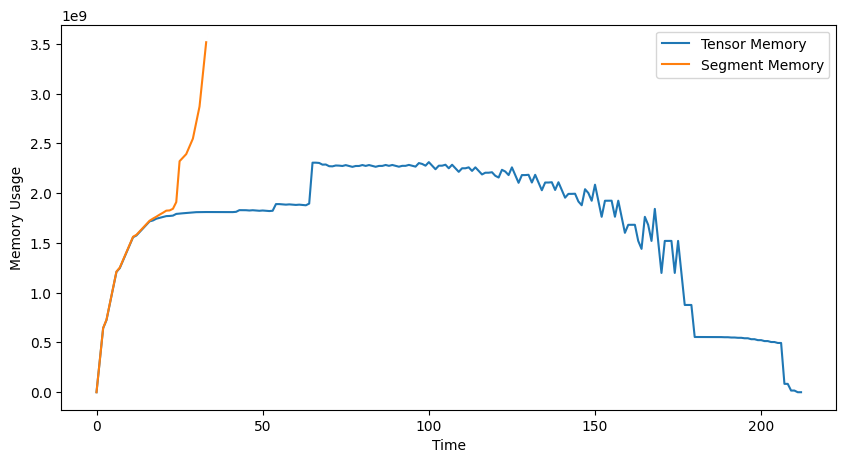

In [26]:
hugging_estimated_instance.plot_memory_change()

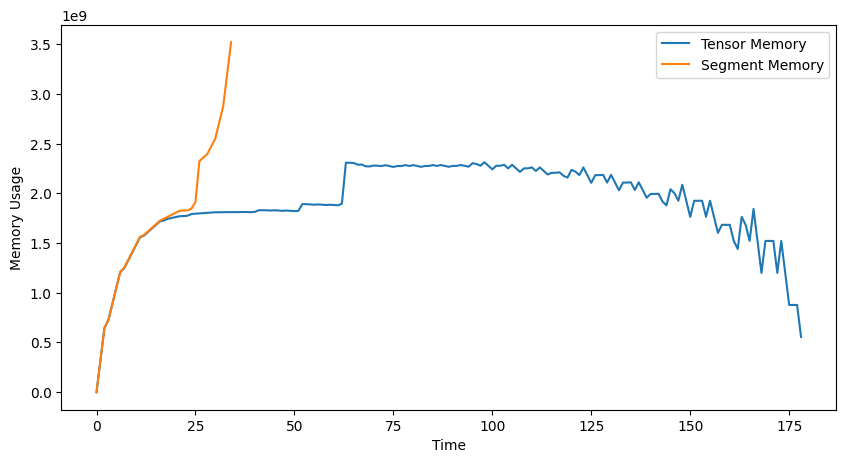

In [22]:
estimated_instance.plot_memory_change()

In [6]:
torch_profiler_file = "/home/glaswigian/DL-Estimator/20250219-200437-df18/results/callback/Profiler/Glaswigian-Researcher_8223.1739995493484167898.pt.trace.json"
_, torch_estimator = get_xmem_memory(torch_profiler_file, batch_size, max_gpu_memory)

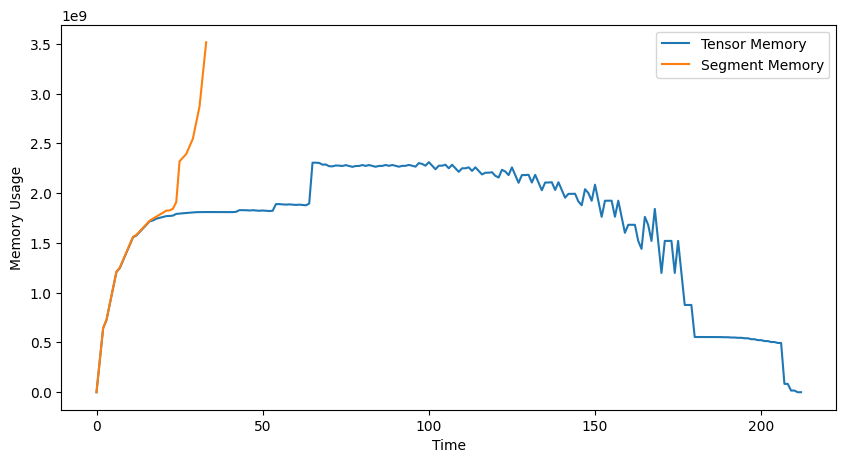

In [9]:
training_memorys = torch_estimator.get_an_iteration_memory(iteration_index=2)
model_memory = torch_estimator.model_memory(iteration=1)
estimated_instance, estimated_result = torch_estimator.memory_estimate(training_memorys)
estimated_instance.plot_memory_change()


In [12]:
for mem in training_memorys:
    if mem.is_backward:
        print(mem.bytes)

680000
680000
2785280
16384000
4000
2785280
2785280
2785280
67108864
16384
2785280
2785280
17059840
411041792
16384
1392640
8704000
8704000
8704000
2048
9437184
8704000
8704000
2048
9437184
8704000
8704000
2048
9437184
34816000
34816000
34816000
2048
9437184
34816000
34816000
2048
9437184
34816000
17408000
2048
4718592
76769280
76769280
76769280
1024
2359296
76769280
76769280
1024
2359296
76769280
38384640
1024
1179648
160936960
160936960
160936960
512
589824
160936960
80468480
512
294912
321873920
321873920
321873920
256
147456
321873920
256
6912


In [37]:
model_memory

[Memory(backward|1401486144|persis): Bytes:6912, Start:0, End:None, Comments: Conv2d_0,
 Memory(backward|1607730944|persis): Bytes:256, Start:1, End:None, Comments: Conv2d_0,
 Memory(backward|1401863232|persis): Bytes:147456, Start:3, End:None, Comments: Conv2d_1,
 Memory(backward|1283917760|persis): Bytes:256, Start:4, End:None, Comments: Conv2d_1,
 Memory(backward|1446590080|persis): Bytes:294912, Start:8, End:None, Comments: Conv2d_2,
 Memory(backward|1283866496|persis): Bytes:512, Start:9, End:None, Comments: Conv2d_2,
 Memory(backward|1625139968|persis): Bytes:589824, Start:12, End:None, Comments: Conv2d_3,
 Memory(backward|1291622336|persis): Bytes:512, Start:13, End:None, Comments: Conv2d_3,
 Memory(backward|1399191168|persis): Bytes:1179648, Start:17, End:None, Comments: Conv2d_4,
 Memory(backward|1687512448|persis): Bytes:1024, Start:18, End:None, Comments: Conv2d_4,
 Memory(backward|1449801536|persis): Bytes:2359296, Start:21, End:None, Comments: Conv2d_5,
 Memory(backward|16